# Circuit analysis tools

In [1]:
import numpy as np
import time
import sys
import math

import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

import qiskit.qasm2

In [2]:
q = qiskit.qasm2.load("circuit_3_60q.qasm")

In [51]:
#PI = np.pi
#qc_len = len(q.data)
#gate_num_list = []
#for i in range(qc_len):
#    cur_gate = q.data[i]
#    qubits_number = len(cur_gate[1])
#    #Get qubits list for current gate
#    if cur_gate[0].name == 'rz':
#        cur_angle = cur_gate[0].params[0]
#        cur_angle = cur_angle%(2*PI)
#        if cur_angle > PI:
#            cur_angle = cur_angle - 2 * PI
#        q.data[i][0].params[0] = cur_angle


In [3]:
cut_start = 0
cut_number = 12

qc_cut = QuantumCircuit(2,2)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

qc_cut.draw('mpl')

CircuitError: "Bit 'Qubit(QuantumRegister(60, 'q'), 37)' is not in the circuit."

## Lighcone s
earch function

In [4]:
#the function finds the last gate using qubit qbit_num in circuit qc
def last_gate(qc, qbit_num):
    qubit_last_gate = -1
    qc_len = len(qc.data)
    for i in range(qc_len - 1, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        found = 0
        for i_q in range(qubits_number):
            if cur_gate[1][i_q]._index == qbit_num:
                qubit_last_gate = i
                found = 1
        if found == 1:
            break
    return qubit_last_gate
        

In [5]:
def light_cone(qc, qbit_num):
    start_point = last_gate(qc, qbit_num)
    qc_len = len(qc.data)
    cone_list = []
    cone_list.append(qbit_num)
    for i in range(start_point, -1, -1):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if qubits particiapating in the gate are in the list of the light cone or not
        if qubits_number > 1:
            if (q_list[0] in cone_list) and (q_list[1] not in cone_list):
                cone_list.append(q_list[1])
            if (q_list[1] in cone_list) and (q_list[0] not in cone_list):
                cone_list.append(q_list[0])
    return cone_list, len(cone_list)

In [50]:
cut_start = 0
cut_number = 4165

qc_cut = QuantumCircuit(60,60)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

In [51]:
for i in range(60):
    [q_list, n] = light_cone(qc_cut, i)
    print(n)

#[q_list, n] = light_cone(qc_cut, 37)
#q_list

24
54
50
48
60
48
54
44
48
60
60
26
60
48
60
56
48
60
24
56
46
26
38
24
54
44
60
48
48
46
40
38
54
28
50
26
12
48
60
56
60
40
60
50
40
48
24
40
50
24
24
26
60
26
60
44
60
54
26
56


# Check how many cz for ceratin pair

In [7]:
def check_how_many_cz(qc, qbit_num_1, qbit_num_2):
    qc_len = len(qc.data)
    gate_num_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        q_list = []
        for i_q in range(qubits_number):
            q_list.append(cur_gate[1][i_q]._index)
        #check if the gate involves both the qubits we want to check
        if qubits_number > 1:
            if (q_list[0] == qbit_num_1 and q_list[1] == qbit_num_2) or (q_list[0] == qbit_num_2 and q_list[1] == qbit_num_1):
                gate_num_list.append(i)
    return gate_num_list

In [8]:
coupling_map = np.zeros((60, 60))

cut_start = 0
cut_number = 7200

qc_cut = QuantumCircuit(60,60)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)

for iq_1 in range(60):
    for iq_2 in range(0, 60):
        coupling_map[iq_1][iq_2] = len(check_how_many_cz(q, iq_1, iq_2))
 

In [11]:
coupling_map[37][:]

array([0., 0., 0., 0., 0., 4., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 9., 9., 0., 2., 0., 0., 0.,
       0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 2., 0., 0., 0., 0., 0., 0., 4.])

In [12]:
coupling_map[35][:]

array([ 2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 13.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  9.,  0.,  2.,  0.,  0.,  0.,  0.])

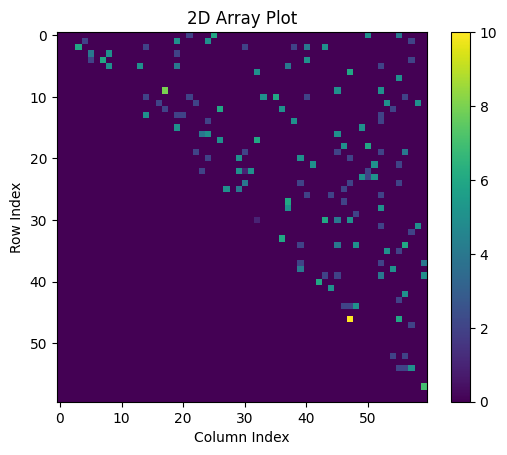

In [59]:
plt.imshow(coupling_map, cmap='viridis')  # Use a colormap for visualization
plt.colorbar()  # Add a colorbar to show value mapping
plt.title('2D Array Plot')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

In [408]:
coupling_map[3]

array([0., 0., 0., 0., 0., 0., 0., 2., 4., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 2., 0., 0., 0., 0., 0.])

In [409]:
tot = []
for i in range(60):
    tot.append(0)
    for j in range(60):
        if (coupling_map[i][j] != 0) or (coupling_map[j][i] != 0):
            tot[i] = tot[i] + coupling_map[i][j] + coupling_map[j][i]

    

In [410]:
print(tot)

[19.0, 24.0, 7.0, 13.0, 15.0, 12.0, 11.0, 21.0, 18.0, 16.0, 21.0, 7.0, 7.0, 14.0, 9.0, 14.0, 8.0, 7.0, 15.0, 12.0, 7.0, 24.0, 8.0, 8.0, 8.0, 7.0, 7.0, 11.0, 8.0, 13.0, 21.0, 9.0, 14.0, 17.0, 7.0, 12.0, 19.0, 11.0, 7.0, 7.0, 7.0, 16.0, 7.0, 7.0, 8.0, 14.0, 7.0, 7.0, 8.0, 12.0, 7.0, 8.0, 8.0, 13.0, 9.0, 13.0, 7.0, 13.0, 7.0, 21.0]


In [205]:
q.data[2][0].params[0]

5.9735141613602165

In [150]:
def check_is_there_identical_z(qc, qbit_num_1):
    qc_len = len(qc.data)
    angles_list = []
    num_id_angles = 0
    n_z = 0
    id_angles_list = []
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        if (cur_gate[0].name == 'rz'):
            n_z = n_z + 1
            cur_angle = cur_gate[0].params[0]
            if cur_angle in angles_list:
                num_id_angles = num_id_angles + 1
                id_angles_list.append(cur_angle)
            else:
                angles_list.append(cur_angle)
                
    return num_id_angles, id_angles_list, n_z

In [151]:
cut_start = 0
cut_number = 7200

qc_cut = QuantumCircuit(60,60)
for q_i in range(cut_start, cut_start + cut_number):
    qc_cut.append(q.data[q_i], qc_cut.qubits, qc_cut.clbits)
check_is_there_identical_z(qc_cut, 4)

(900,
 [2.353304971691044,
  5.9735141613602165,
  4.599253580133889,
  3.761482191925223,
  0.980294029274052,
  0.9801424781769557,
  0.3649500985631483,
  5.442345232562516,
  3.776917009710014,
  4.448951217224888,
  0.12933619211510794,
  6.094123332392967,
  5.230391369746984,
  1.3341659803533248,
  1.1424399624340646,
  1.152364521581569,
  1.9116103907867292,
  3.297141901079666,
  2.713990594641554,
  1.8298466547148808,
  3.844385118274953,
  0.8764657756906659,
  1.8355989632476268,
  2.3019193508941536,
  2.865572223878106,
  4.933406064175189,
  1.2545873742863833,
  3.23103026788615,
  3.7222505148331146,
  0.29185655071471744,
  3.8173168869197154,
  1.0714346684716647,
  0.4087312132537349,
  5.962023665865352,
  6.067245002356024,
  5.0793103400482895,
  1.9139447588347167,
  0.6136919916460806,
  4.299162898868205,
  2.7655596815831176,
  0.7667888440908461,
  3.1112882860657196,
  0.21606945060677518,
  5.713428589860037,
  1.62596257818143,
  4.162750282731995,
  1

In [212]:
#for i in range(60):
#    print(check_is_there_identical_z(q, i))

In [152]:
def check_connections(qc, qbit_list):
    qc_len = len(qc.data)
    n_conn = 0
    for i in range(qc_len):
        cur_gate = qc.data[i]
        qubits_number = len(cur_gate[1])
        #Get qubits list for current gate
        if (cur_gate[0].name == 'cz'):
            if (cur_gate[1][0]._index in qbit_list) and (cur_gate[1][1]._index not in qbit_list):
                n_conn = n_conn + 1
                
    return n_conn

In [153]:
import random
min_conn_nub = 100000
for i in range(10000):
    full_qbit_list = range(60)
    qbit_list = random.sample(full_qbit_list, 10)
    nn = check_connections(q, qbit_list)
    if nn < min_conn_nub:
        min_conn_nub = nn
min_conn_nub

57

In [154]:
ii = 40
check_connections(q, range(ii,ii + 10))

107

In [155]:
6%4

2

In [156]:
def block_analysis(qc):
    qc_len = len(qc.data)
    n_blocks = 0
    block_str = []
    block_angles = []
    
    new_block_str = ''
    new_block_ang = []
    
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if (cur_gate[0].name == 'cz'):
            block_str.append(new_block_str)
            block_angles.append(new_block_ang)
            n_blocks = n_blocks + 1
            new_block_str = ''
            new_block_ang = []
        else:
            if (cur_gate[0].name == 'rz'):
                cur_angle = cur_gate[0].params[0]
                new_block_ang.append(cur_angle)
                new_block_str = new_block_str + 'z '
            if (cur_gate[0].name == 'sx'):
                new_block_str = new_block_str + '_x '
            if (cur_gate[0].name == 'x'):
                new_block_str = new_block_str + 'x '
    return n_blocks, block_str, block_angles



In [157]:
block_analysis(q)

(862,
 ['z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x x z z _x z _x x z ',
  'z _x z _x z _x z x _x z z _x z _x x z _x z _x x z _x z x _x z _x z _x z _x z z _x z _x z _x z _x z _x z ',
  'z _x z x _x z z _x z _x z x z ',
  'z _x z x _x z z _x z _x z ',
  'z _x z _x z z _x z x _x z ',
  'z _x z _x z z _x z x z 

In [158]:
qc_z = QuantumCircuit(60,60)
for q_i in range(7200):
    cur_gate = q.data[q_i]
    if (cur_gate[0].name == 'rz'):
        qc_z.append(q.data[q_i], qc_z.qubits, qc_z.clbits)

#qc_z.draw('mpl')

In [159]:
len(qc_z)

3393

In [160]:
def check_is_there_identical_z_1(qc):
    qc_len = len(qc.data)
    pair = []
    for i in range(qc_len):
        pp = []
        cur_gate = qc.data[i]
        cur_angle = cur_gate[0].params[0]
        pp.append(cur_gate[1][0]._index)
        for j in range(qc_len):
            if i != j:
                cur_gate_1 = qc.data[j]
                cur_angle_1 = cur_gate_1[0].params[0]
                if cur_angle_1 == cur_angle:
                    pp.append(cur_gate_1[1][0]._index)
                    break
        pair.append(pp)
    return pair

In [161]:
check_is_there_identical_z_1(qc_z)

[[37, 35],
 [37, 35],
 [37, 35],
 [27, 10],
 [27, 10],
 [27, 10],
 [25, 33],
 [25, 33],
 [25, 33],
 [0, 36],
 [0, 36],
 [0, 36],
 [50, 12],
 [50, 12],
 [50, 12],
 [18, 26],
 [18, 26],
 [18, 26],
 [46, 17],
 [46, 17],
 [46, 17],
 [55, 32],
 [55, 32],
 [55, 32],
 [7, 6],
 [7, 6],
 [7, 6],
 [4, 47],
 [4, 47],
 [4, 47],
 [40, 30],
 [40, 30],
 [40, 30],
 [42, 43],
 [42, 43],
 [42, 43],
 [56, 2],
 [56, 2],
 [56, 2],
 [34, 3],
 [34, 3],
 [34, 3],
 [48, 8],
 [48, 8],
 [48, 8],
 [44, 5],
 [44, 5],
 [44, 5],
 [41, 13],
 [41, 13],
 [41, 13],
 [21, 14],
 [21, 14],
 [21, 14],
 [51, 38],
 [51, 38],
 [51, 38],
 [23, 54],
 [23, 54],
 [23, 54],
 [49, 57],
 [49, 57],
 [49, 57],
 [15, 59],
 [15, 59],
 [15, 59],
 [19, 39],
 [19, 39],
 [35, 37],
 [35, 37],
 [35, 37],
 [10, 27],
 [10, 27],
 [10, 27],
 [33, 25],
 [33, 25],
 [33, 25],
 [36, 0],
 [36, 0],
 [36, 0],
 [12, 50],
 [12, 50],
 [12, 50],
 [26, 18],
 [26, 18],
 [26, 18],
 [17, 46],
 [17, 46],
 [17, 46],
 [32, 55],
 [32, 55],
 [32, 55],
 [6, 7],
 [6, 7

In [43]:
#Qubits rearragement
qubits_rearr_table = []
qubits_rearr_table.append([0,0])
qubits_rearr_table.append([1,1])
qubits_rearr_table.append([2,2])
qubits_rearr_table.append([3,3])
qubits_rearr_table.append([4,4])
qubits_rearr_table.append([5,5])
qubits_rearr_table.append([6,6])
qubits_rearr_table.append([7,36])
qubits_rearr_table.append([8,7])
qubits_rearr_table.append([9,8])
qubits_rearr_table.append([10,9])
qubits_rearr_table.append([11,10])
qubits_rearr_table.append([12,11])
qubits_rearr_table.append([13,12])
qubits_rearr_table.append([14,13])
qubits_rearr_table.append([15,14])
qubits_rearr_table.append([16,15])
qubits_rearr_table.append([17,16])
qubits_rearr_table.append([18,17])
qubits_rearr_table.append([19,18])
qubits_rearr_table.append([20,31])
qubits_rearr_table.append([21,43])
qubits_rearr_table.append([22,45])
qubits_rearr_table.append([23,19])
qubits_rearr_table.append([24,20])
qubits_rearr_table.append([25,21])
qubits_rearr_table.append([26,47])
qubits_rearr_table.append([27,39])
qubits_rearr_table.append([28,22])
qubits_rearr_table.append([29,50])
qubits_rearr_table.append([30,23])
qubits_rearr_table.append([31,24])
qubits_rearr_table.append([32,25])
qubits_rearr_table.append([33,51])
qubits_rearr_table.append([34,33])
qubits_rearr_table.append([35,26])
qubits_rearr_table.append([36,30])
qubits_rearr_table.append([37,56])
qubits_rearr_table.append([38,27])
qubits_rearr_table.append([39,48])
qubits_rearr_table.append([40,53])
qubits_rearr_table.append([41,42])
qubits_rearr_table.append([42,28])
qubits_rearr_table.append([43,58])
qubits_rearr_table.append([44,35])
qubits_rearr_table.append([45,54])
qubits_rearr_table.append([46,46])
qubits_rearr_table.append([47,34])
qubits_rearr_table.append([48,37])
qubits_rearr_table.append([49,29])
qubits_rearr_table.append([50,41])
qubits_rearr_table.append([51,57])
qubits_rearr_table.append([52,40])
qubits_rearr_table.append([53,52])
qubits_rearr_table.append([54,49])
qubits_rearr_table.append([55,55])
qubits_rearr_table.append([56,32])
qubits_rearr_table.append([57,59])
qubits_rearr_table.append([58,38])
qubits_rearr_table.append([59,44])

In [47]:
def reorganize_qubits(qc):
    qc_len = len(qc.data)
    qc_re = QuantumCircuit(60,60)
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.RZGate(cur_angle_1)
            qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.SXGate()
            qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            new_ind = qubits_rearr_table[curr_q][1]
            gate = qiskit.circuit.library.XGate()
            qc_re.append(gate, [new_ind])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            new_ind_1 = qubits_rearr_table[curr_q_1][1]
            curr_q_2 = cur_gate[1][1]._index
            new_ind_2 = qubits_rearr_table[curr_q_2][1]
            #print([curr_q_1,curr_q_2])
            gate = qiskit.circuit.library.CZGate()
            qc_re.append(gate, [new_ind_1, new_ind_2])  
    
    return qc_re

In [48]:
q.data[12][1][1]

Qubit(QuantumRegister(60, 'q'), 27)

In [49]:
qc_re = reorganize_qubits(q)

In [51]:
qc_re[12]

CircuitInstruction(operation=Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(60, 'q'), 56), Qubit(QuantumRegister(60, 'q'), 39)), clbits=())

In [125]:
cut_start = 0
cut_number = 7200

qc_re_cut = QuantumCircuit(60,60)
for q_i in range(cut_start, cut_start + cut_number):
    qc_re_cut.append(qc_re.data[q_i], qc_cut.qubits, qc_cut.clbits)
len(qc_re_cut)

7200

In [127]:
#qc_re_cut.draw('mpl')

In [164]:
coupling_map = np.zeros((60, 60))

for iq_1 in range(60):
    for iq_2 in range(iq_1, 60):
        coupling_map[iq_1][iq_2] = len(check_how_many_cz(q, iq_1, iq_2))
 

NameError: name 'check_how_many_cz' is not defined

In [ ]:
coupling_map[0][:]

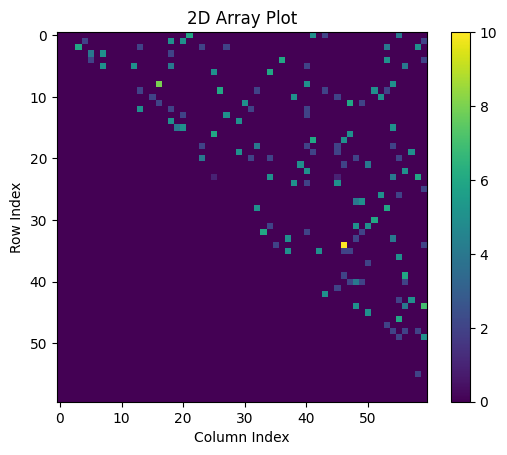

In [129]:
plt.imshow(coupling_map, cmap='viridis')  # Use a colormap for visualization
plt.colorbar()  # Add a colorbar to show value mapping
plt.title('2D Array Plot')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

In [104]:
def two_qubits_circuit(qc, q_list):
    qc_len = len(qc.data)
    qc_re = QuantumCircuit(60,60)
    for i in range(7200):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                qc_re.append(gate, [curr_q])
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                gate = qiskit.circuit.library.SXGate()
                qc_re.append(gate, [curr_q])
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if curr_q in q_list:
                gate = qiskit.circuit.library.XGate()
                qc_re.append(gate, [curr_q])
        if cur_gate[0].name == 'cz':
            curr_q_1 = cur_gate[1][0]._index
            curr_q_2 = cur_gate[1][1]._index
            if curr_q_1 in q_list or curr_q_2 in q_list:
                gate = qiskit.circuit.library.CZGate()
                qc_re.append(gate, [curr_q_1, curr_q_2])  
    
    return qc_re

In [119]:
qc_2q = two_qubits_circuit(q, [37, 35, 27, 10])

In [120]:
len(qc_2q)

513

In [121]:
qc_2q.draw('mpl')

In [129]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

def operator_an(qc, q_1):
    qc_len = len(qc.data)
    qc_loc = QuantumCircuit(1)
    counter = 0
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if curr_q == q_1:
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                qc_loc.append(gate, [0])
                counter = counter + 1
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if curr_q == q_1:
                gate = qiskit.circuit.library.SXGate()
                qc_loc.append(gate, [0])
                counter = counter + 1
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if curr_q == q_1:
                gate = qiskit.circuit.library.XGate()
                qc_loc.append(gate, [0])
                counter = counter + 1
        if (cur_gate[0].name == 'cz') and ((cur_gate[1][0]._index == q_1) or (cur_gate[1][1]._index == q_1)):
            print(counter)
            print([cur_gate[1][0]._index, cur_gate[1][1]._index])
            op = Operator(qc_loc)
            display(array_to_latex(op, precision=1))
            qc_loc = QuantumCircuit(1)
            counter = 0
    
    return 0

In [125]:
a  = operator_an(q, 46)

6
[46, 55]


<IPython.core.display.Latex object>

6
[46, 47]


<IPython.core.display.Latex object>

6
[46, 47]


...

<IPython.core.display.Latex object>

6
[46, 55]


<IPython.core.display.Latex object>

6
[18, 46]


<IPython.core.display.Latex object>

In [126]:
a  = operator_an(q, 47)

6
[6, 47]


<IPython.core.display.Latex object>

6
[46, 47]


<IPython.core.display.Latex object>

5
[46, 47]


...

<IPython.core.display.Latex object>

6
[6, 47]


<IPython.core.display.Latex object>

6
[47, 30]


<IPython.core.display.Latex object>

In [145]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

def operator_an_2(qc, q_1, q_2):
    qc_len = len(qc.data)
    qc_loc = QuantumCircuit(2)
    counter = 0
    for i in range(qc_len):
        cur_gate = qc.data[i]
        if cur_gate[0].name == 'rz':
            cur_angle_1 = cur_gate[0].params[0]
            curr_q = cur_gate[1][0]._index
            if (curr_q == q_1) or (curr_q == q_2):
                gate = qiskit.circuit.library.RZGate(cur_angle_1)
                if curr_q == q_1:
                    gg = 0
                else:
                    gg = 1
                qc_loc.append(gate, [gg])
                counter = counter + 1
        if cur_gate[0].name == 'sx':
            curr_q = cur_gate[1][0]._index
            if (curr_q == q_1) or (curr_q == q_2):
                gate = qiskit.circuit.library.SXGate()
                if curr_q == q_1:
                    gg = 0
                else:
                    gg = 1
                qc_loc.append(gate, [gg])
                counter = counter + 1
        if cur_gate[0].name == 'x':
            curr_q = cur_gate[1][0]._index
            if (curr_q == q_1) or (curr_q == q_2):
                gate = qiskit.circuit.library.XGate()
                if curr_q == q_1:
                    gg = 0
                else:
                    gg = 1
                qc_loc.append(gate, [gg])
                counter = counter + 1
        if (cur_gate[0].name == 'cz') and ((cur_gate[1][0]._index == q_1) or (cur_gate[1][1]._index == q_1)):
            print(counter)
            print([cur_gate[1][0]._index, cur_gate[1][1]._index])
            op = Operator(qc_loc)
            display(array_to_latex(op, precision=1))
            #qc_loc = QuantumCircuit(1)
            counter = 0
            if (cur_gate[0].name == 'cz') and ((cur_gate[1][0]._index == q_1) and (cur_gate[1][1]._index == q_2)):
                qc_loc.cz(0,1)
            op = Operator(qc_loc)
            display(array_to_latex(op, precision=1))
    
    return 0

In [146]:
operator_an_2(q, 46, 47)

6
[46, 55]


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

18
[46, 47]


<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

12
[18, 46]


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

0